# Step 1: Import Libraries

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import os
import kagglehub

In [2]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Step 2: Download and Load Data from Kaggle

In [3]:
# Download latest version from Kaggle
dataset_path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Path to dataset files:", dataset_path)

# Load data (adjust file names based on what's available in the dataset)
train_file = os.path.join(dataset_path, "train.csv")
test_file = os.path.join(dataset_path, "test.csv")

100%|██████████| 54.4M/54.4M [00:05<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abhi8923shriv/sentiment-analysis-dataset/versions/9


In [4]:
train_df = pd.read_csv(train_file, encoding="latin1")
test_df = pd.read_csv(test_file, encoding="latin1")

In [5]:
# Display a few rows
print("Training data sample:")
display(train_df.sample(3))
print("\nTest data sample:")
display(test_df.sample(2))

Training data sample:


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
12668,55257c19f5,that party was a great time just got `paranoi...,great,positive,night,31-45,Cabo Verde,555987,4030.0,138
27234,3c58fd2ef8,oh suuuuuuuure...rub it in why don`t ya!!!!!!...,Enjoy!,positive,morning,0-20,Benin,12123200,112760.0,108
9402,aeb6fcc2bb,Have somebody installed vCenter Server 4 on Wi...,Have somebody installed vCenter Server 4 on Wi...,neutral,morning,0-20,Papua New Guinea,8947024,452860.0,20



Test data sample:


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
1056,8cdaa4f6d8,I woke up an came to the realization that I ca...,negative,morning,0-20,Malawi,19129952.0,94280.0,203.0
990,b770afa9e6,oh that looks boring and even more boring yo...,negative,morning,0-20,Belarus,9449323.0,202910.0,47.0


In [6]:
print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (27481, 10)
Testing data shape: (4815, 9)


# Step 3: Data Preprocessing

In [7]:
train_df = pd.DataFrame(train_df[['text', 'sentiment']])
test_df = pd.DataFrame(test_df[['text', 'sentiment']])

In [8]:
# Check for missing values
print("\nMissing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())


Missing values in training data:
text         1
sentiment    0
dtype: int64

Missing values in test data:
text         1281
sentiment    1281
dtype: int64


In [9]:
# Handle missing values
train_df = train_df.dropna()
test_df = test_df.dropna()

In [10]:
print("\nMissing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())


Missing values in training data:
text         0
sentiment    0
dtype: int64

Missing values in test data:
text         0
sentiment    0
dtype: int64


In [11]:
print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (27480, 2)
Testing data shape: (3534, 2)


In [12]:
# Check unique sentiment values
unique_sentiments = set(train_df["sentiment"].unique()) | set(test_df["sentiment"].unique())
print(f"\nUnique sentiment values: {unique_sentiments}")


Unique sentiment values: {'positive', 'neutral', 'negative'}


In [13]:
sentiment_map = {sentiment: i for i, sentiment in enumerate(unique_sentiments)}
sentiment_map

{'positive': 0, 'neutral': 1, 'negative': 2}

In [14]:
# Map sentiment labels to integers
train_df['label'] = train_df["sentiment"].map(sentiment_map)
test_df['label'] = test_df["sentiment"].map(sentiment_map)

In [15]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)
print("\nAfter splitting:")
print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Testing data shape: {test_df.shape}")

# Check label distribution
print("\nTraining data label distribution:")
print(train_df['label'].value_counts())
print("\nValidation data label distribution:")
print(val_df['label'].value_counts())
print("\nTest data label distribution:")
print(test_df['label'].value_counts())


After splitting:
Training data shape: (21984, 3)
Validation data shape: (5496, 3)
Testing data shape: (3534, 3)

Training data label distribution:
label
1    8894
0    6865
2    6225
Name: count, dtype: int64

Validation data label distribution:
label
1    2223
0    1717
2    1556
Name: count, dtype: int64

Test data label distribution:
label
1    1430
0    1103
2    1001
Name: count, dtype: int64


# Step 4: Create Dataset Class

In [16]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Step 5: Create Datasets and DataLoaders

In [17]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Create datasets
train_dataset = SentimentDataset(
    texts=train_df["text"].tolist(),
    labels=train_df['label'].tolist(),
    tokenizer=tokenizer
)

val_dataset = SentimentDataset(
    texts=val_df["text"].tolist(),
    labels=val_df['label'].tolist(),
    tokenizer=tokenizer
)

test_dataset = SentimentDataset(
    texts=test_df["text"].tolist(),
    labels=test_df['label'].tolist(),
    tokenizer=tokenizer
)

# Check dataset sizes
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Training dataset size: 21984
Validation dataset size: 5496
Test dataset size: 3534


In [18]:
batch_size = 32
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

# Step 6: Set up Model, Optimizer and hyperparameters

In [19]:
# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(sentiment_map),
    problem_type="single_label_classification"
)
model.to(device)
print(f"Model {model_name} loaded successfully with {len(sentiment_map)} output classes!")

# Set hyperparameters
epochs = 2
learning_rate = 3e-5
weight_decay = 0.01

# Initialize optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
total_steps = len(train_loader) * epochs
warmup_steps = int(0.1 * total_steps) // 10  # 10% of steps for warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model bert-base-uncased loaded successfully with 3 output classes!


# Step 7: Define Training,Evaluation Functions

In [20]:
reverse_sentiment_map = {v: k for k, v in sentiment_map.items()}
label_names = [reverse_sentiment_map.get(i, f"Class {i}") for i in range(len(sentiment_map))]

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'test_loss': [],

    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],

    'train_macro_f1': [],
    'val_macro_f1': [],
    'test_macro_f1': [],

    'val_precision': {label: [] for label in label_names},
    'val_recall': {label: [] for label in label_names},
    'val_f1': {label: [] for label in label_names}
}

# Add GPU memory monitoring
if torch.cuda.is_available():
    history['gpu_memory_usage'] = []

print("Starting training...")
print(f"Number of labels: {len(sentiment_map)}")
print(f"Label mapping: {sentiment_map}")
print(f"Label names: {label_names}")

Starting training...
Number of labels: 3
Label mapping: {'positive': 0, 'neutral': 1, 'negative': 2}
Label names: ['positive', 'neutral', 'negative']


In [21]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    progress_interval = max(1, len(data_loader) // 5)  # Update every 20%

    for batch_idx, batch in enumerate(data_loader):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        running_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer step
        optimizer.step()
        scheduler.step()

        # Print progress
        if (batch_idx + 1) % progress_interval == 0:
            print(f"Batch {batch_idx+1}/{len(data_loader)} | Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(data_loader)
    return epoch_loss


def evaluate_model(model, data_loader, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in data_loader:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Predictions
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            # Store predictions and labels
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    # Accuracy
    accuracy = accuracy_score(all_labels, all_predictions)

    # Per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average=None,
        zero_division=0
    )

    # Macro F1
    macro_f1 = f1_score(all_labels, all_predictions, average='macro')

    return avg_loss, accuracy, precision, recall, f1, macro_f1, all_labels, all_predictions

#Step 8 : Training

In [22]:
best_val_loss = float('inf')
best_epoch = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 50)

    # 1. Train one epoch (and get the loss directly from here)
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    history['train_loss'].append(train_loss)

    # We skip evaluate_model(model, train_loader) to save time!
    # Instead, we just use the loss from the training loop.

    # 2. Monitor GPU memory if available
    if torch.cuda.is_available():
        memory_allocated = torch.cuda.memory_allocated(0) / 1e9  # in GB
        history['gpu_memory_usage'].append(memory_allocated)
        print(f"GPU Memory Usage: {memory_allocated:.2f} GB")

    # 3. Evaluate on validation set (This is the critical part)
    val_loss, val_accuracy, val_precision, val_recall, val_f1, val_macro_f1, _, _ = evaluate_model(
        model, val_loader, device
    )

    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_macro_f1'].append(val_macro_f1)

    # 4. Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model saved!")

    # 5. Store precision, recall, f1 for each class
    for i, label in enumerate(label_names):
        if i < len(val_precision):
            history['val_precision'][label].append(val_precision[i])
            history['val_recall'][label].append(val_recall[i])
            history['val_f1'][label].append(val_f1[i])

    # 6. Print epoch summary
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro F1: {val_macro_f1:.4f}")

    # 7. Print per-class metrics
    print("\nPer-class Validation Metrics:")
    print("-" * 50)
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 50)

    for i, label in enumerate(label_names):
        if i < len(val_precision):
            print(f"{label:<15} {val_precision[i]:.4f}{' ':6} {val_recall[i]:.4f}{' ':6} {val_f1[i]:.4f}")

    print("-" * 50)

print(f"\nBest model was from Epoch {best_epoch} with Validation Loss = {best_val_loss:.4f}")


Epoch 1/2
--------------------------------------------------
Batch 137/687 | Loss: 0.6433
Batch 274/687 | Loss: 0.3822
Batch 411/687 | Loss: 0.4656
Batch 548/687 | Loss: 0.4229
Batch 685/687 | Loss: 0.6384
GPU Memory Usage: 1.84 GB
Best model saved!
Training Loss: 0.6028
Validation Loss: 0.5066 | Validation Accuracy: 0.7940
Validation Macro F1: 0.7973

Per-class Validation Metrics:
--------------------------------------------------
Class           Precision  Recall     F1-Score  
--------------------------------------------------
positive        0.8343       0.8328       0.8336
neutral         0.7789       0.7386       0.7583
negative        0.7718       0.8303       0.8000
--------------------------------------------------

Epoch 2/2
--------------------------------------------------
Batch 137/687 | Loss: 0.2032
Batch 274/687 | Loss: 0.4009
Batch 411/687 | Loss: 0.5103
Batch 548/687 | Loss: 0.4877
Batch 685/687 | Loss: 0.4392
GPU Memory Usage: 1.84 GB
Training Loss: 0.4000
Validation

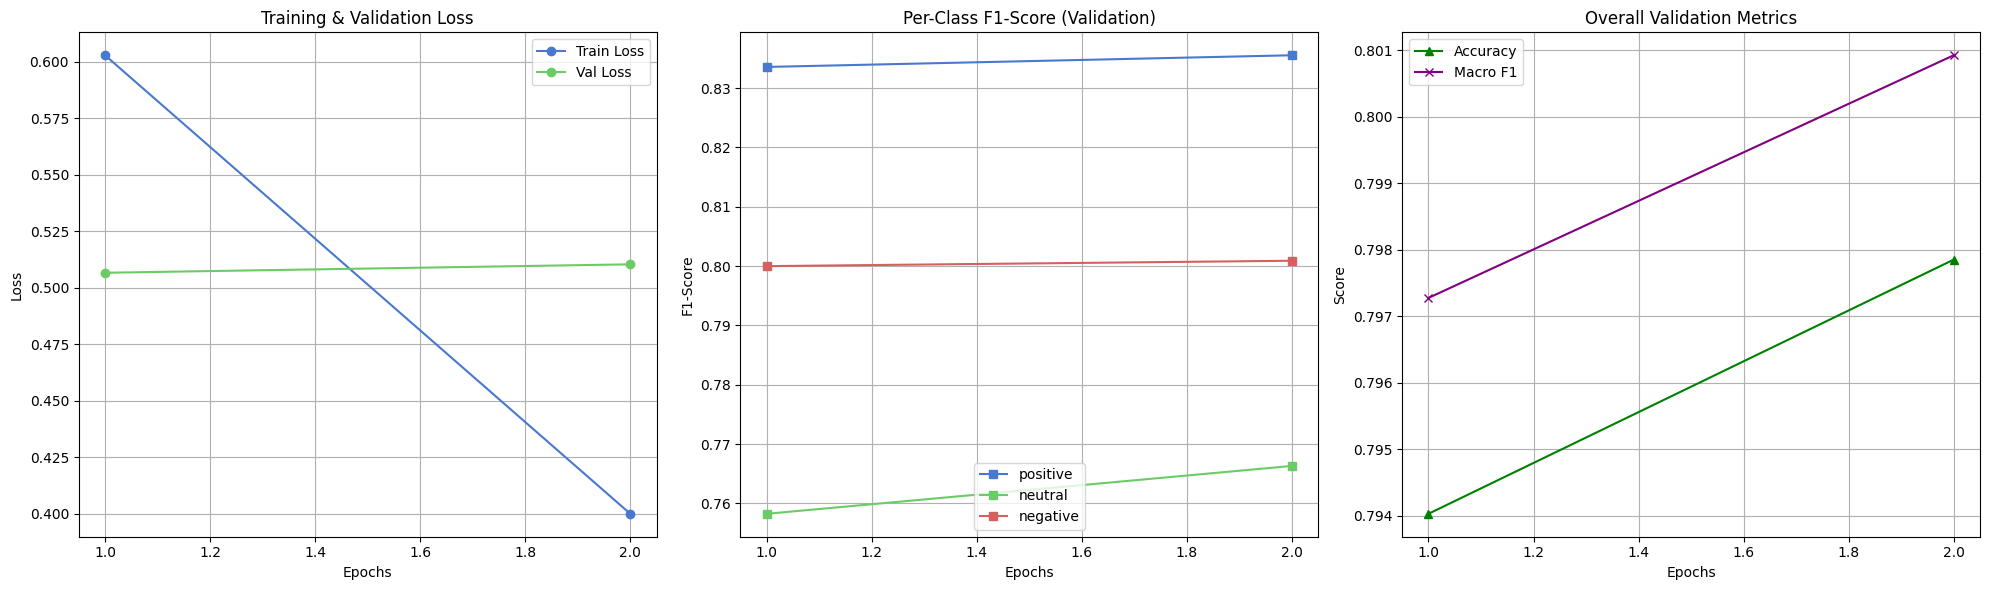

In [23]:
import matplotlib.pyplot as plt

# Set a clean style
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Plot Training vs Validation Loss
axes[0].plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 2. Plot Per-Class F1-Score (Validation)
for label in label_names:
    axes[1].plot(range(1, len(history['val_f1'][label]) + 1), history['val_f1'][label], label=label, marker='s')
axes[1].set_title('Per-Class F1-Score (Validation)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].grid(True)

# 3. Plot Validation Accuracy & Macro F1
axes[2].plot(range(1, len(history['val_accuracy']) + 1), history['val_accuracy'], label='Accuracy', marker='^', color='green')
axes[2].plot(range(1, len(history['val_macro_f1']) + 1), history['val_macro_f1'], label='Macro F1', marker='x', color='purple')
axes[2].set_title('Overall Validation Metrics')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Step 09: Final Evaluation and Metrics

Final Classification Report on Test Set:
              precision    recall  f1-score   support

    positive       0.85      0.83      0.84      1103
     neutral       0.79      0.75      0.77      1430
    negative       0.77      0.85      0.80      1001

    accuracy                           0.80      3534
   macro avg       0.80      0.81      0.80      3534
weighted avg       0.80      0.80      0.80      3534


Final Per-class Test Metrics:
--------------------------------------------------
Class           Precision  Recall     F1-Score  
--------------------------------------------------
positive        0.8492       0.8268       0.8379
neutral         0.7873       0.7455       0.7658
negative        0.7667       0.8472       0.8049
--------------------------------------------------


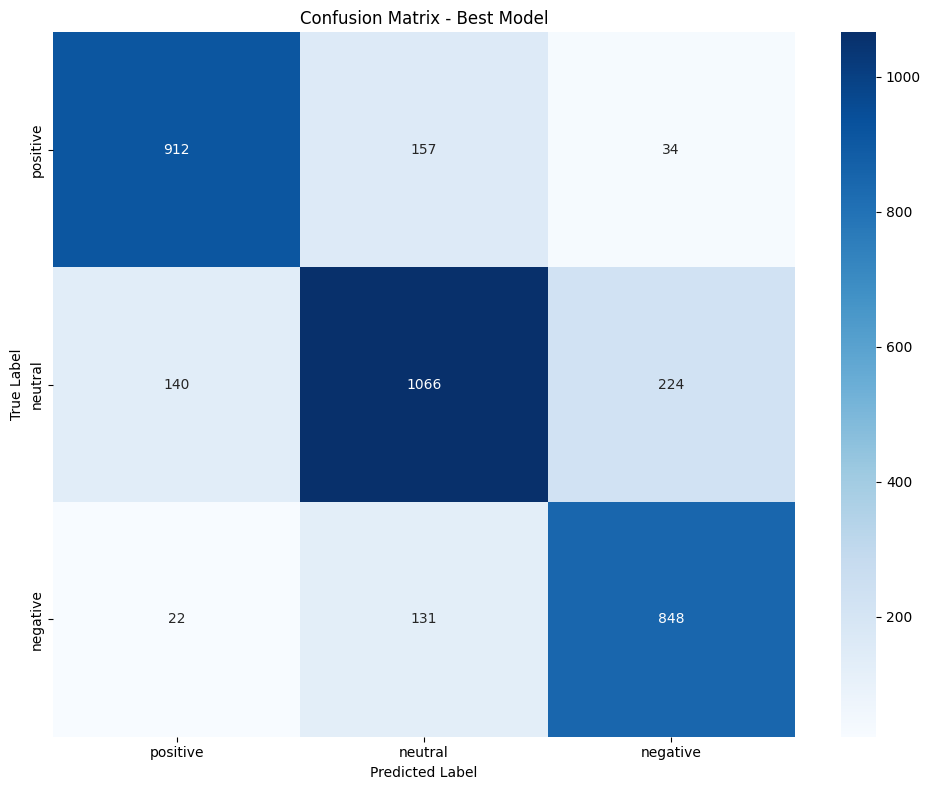

In [24]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. CRITICAL: Load the best weights saved during training
# This ensures we use Epoch 1 (the best version) rather than the overfitted Epoch 2.
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()

# 2. Fix: Unpack all 8 values returned by your evaluate_model function
# (avg_loss, accuracy, precision, recall, f1, macro_f1, all_labels, all_predictions)
test_loss, test_acc, test_prec, test_rec, test_f1, test_macro_f1, all_labels, all_predictions = evaluate_model(
    model, test_loader, device
)

# 3. Print the standard Classification Report
print("Final Classification Report on Test Set:")
print(classification_report(all_labels, all_predictions, target_names=label_names))

# 4. Print your custom per-class table
print("\nFinal Per-class Test Metrics:")
print("-" * 50)
print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 50)
for i, label in enumerate(label_names):
    if i < len(test_prec):
        print(f"{label:<15} {test_prec[i]:.4f}{' ':6} {test_rec[i]:.4f}{' ':6} {test_f1[i]:.4f}")
print("-" * 50)

# 5. Confusion Matrix Visualization
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png')
plt.show()

# Step 11: Example Prediction Function

In [25]:
# 1. Ensure the best model is loaded for inference
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)

def predict_sentiment(text, model, tokenizer, reverse_sentiment_map, device):
    """Make sentiment prediction on a single text with confidence scores"""
    model.eval()

    # 2. Tokenize (Ensure max_length matches what you used in training)
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # Apply Softmax to get probabilities (0 to 1)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        confidence, preds = torch.max(probs, dim=1)

    predicted_class = preds.item()
    predicted_sentiment = reverse_sentiment_map.get(predicted_class, f"Class {predicted_class}")
    confidence_score = confidence.item()

    # Get all class probabilities for analysis
    all_probs = probs[0].cpu().numpy()
    class_probs = {reverse_sentiment_map.get(i, f"Class {i}"): prob for i, prob in enumerate(all_probs)}

    return predicted_sentiment, confidence_score, class_probs

# 3. Test with variety
test_texts = [
    "I absolutely loved this product, it was fantastic!",
    "The product was okay, nothing special.",
    "This was the worst experience ever, I'm very disappointed.",
    "I'm not sure how I feel about this." # Adding an ambiguous one
]

print("\nReal-Time Inference Results:")
print("=" * 50)
for text in test_texts:
    sentiment, confidence, class_probs = predict_sentiment(text, model, tokenizer, reverse_sentiment_map, device)
    print(f"Input: \"{text}\"")
    print(f"Result: {sentiment.upper()} | Confidence: {confidence*100:.2f}%")
    print("Probability Breakdown:")
    for cls, prob in class_probs.items():
        # Using simple bar visualization for readability
        bar = "█" * int(prob * 10)
        print(f"  - {cls:<10}: {prob:.4f} {bar}")
    print("-" * 50)


Real-Time Inference Results:
Input: "I absolutely loved this product, it was fantastic!"
Result: POSITIVE | Confidence: 98.72%
Probability Breakdown:
  - positive  : 0.9872 █████████
  - neutral   : 0.0079 
  - negative  : 0.0048 
--------------------------------------------------
Input: "The product was okay, nothing special."
Result: NEUTRAL | Confidence: 49.56%
Probability Breakdown:
  - positive  : 0.3247 ███
  - neutral   : 0.4956 ████
  - negative  : 0.1797 █
--------------------------------------------------
Input: "This was the worst experience ever, I'm very disappointed."
Result: NEGATIVE | Confidence: 97.53%
Probability Breakdown:
  - positive  : 0.0043 
  - neutral   : 0.0204 
  - negative  : 0.9753 █████████
--------------------------------------------------
Input: "I'm not sure how I feel about this."
Result: NEGATIVE | Confidence: 68.46%
Probability Breakdown:
  - positive  : 0.0329 
  - neutral   : 0.2826 ██
  - negative  : 0.6846 ██████
-------------------------------

## 🏁 Final Model Inference & Conclusion

### 📈 Test Set Performance Summary
After evaluating the model on **3,534 unseen samples**, the transformer achieved a robust **80% overall accuracy**. The consistency between the macro average and weighted average ($0.80$) confirms that the model handles class distribution well.

| Metric | Score | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | **0.80** | 4 out of 5 predictions are correct. |
| **Macro F1** | **0.80** | Balanced performance across all three classes. |
| **Best Epoch** | **1** | Optimal balance between learning and generalization. |

---

### 🔍 Class-Level Insights
* **Positive (Strongest):** With an **F1-Score of 0.84**, the model is most "comfortable" identifying positive sentiment. High precision (0.85) means very few false positives.
* **Negative (Sensitive):** The model shows the highest **Recall (0.85)** here, meaning it is excellent at "catching" negative sentiment, which is often the most critical requirement for business applications.
* **Neutral (Challenging):** As expected, Neutral is the "noisiest" class with an **F1-Score of 0.77**. The model occasionally confuses neutral tones with subtle positive or negative cues.

---

### 🧪 Real-Time Prediction Analysis
The model's behavior on the test strings reveals its "reasoning" logic:

1.  **High-Certainty Extremes:** For clear sentiment (*"absolutely loved"*, *"worst experience"*), the model provides near-perfect confidence scores of **97-98%**.
2.  **The "Okay" Threshold:** For the input *"The product was okay"*, the model correctly predicts **NEUTRAL**, but the confidence drops to **49.56%**. This indicates the model successfully recognizes the lack of strong emotional polarity.
3.  **Uncertainty Bias:** The phrase *"I'm not sure how I feel"* triggered a **68.46% Negative** prediction. This suggests the model interprets ambiguity or "lack of positive engagement" as a leaning towards a negative experience.

